# Task 04 – Graph Neural Network Development (Model 1: GCN)

**Course Module:** CCS4354 – Tensors and Graphs  
**Architecture:** Spectral Graph Convolutional Network (GCN)  

---
### Required Theoretical Explanations:
1. **Architecture Design:**
   $$\mathbf{H}^{(l+1)} = \sigma\left(\mathbf{\tilde{D}}^{-\frac{1}{2}} \mathbf{\tilde{A}} \mathbf{\tilde{D}}^{-\frac{1}{2}} \mathbf{H}^{(l)} \mathbf{W}^{(l)}\right)$$
   - Uses symmetric degree-normalized isotropic aggregation ($\mathbf{\tilde{D}}^{-\frac{1}{2}} \mathbf{\tilde{A}} \mathbf{\tilde{D}}^{-\frac{1}{2}}$) where $\mathbf{\tilde{A}} = \mathbf{A} + \mathbf{I}_N$.
   - Normalizes messages so that high-degree hub nodes do not dominate lower-degree nodes.

2. **Layer Selection:**
   - **2-Layer Depth:** A 2-layer GCN captures the **2-hop citation neighborhood** (papers cited by papers cited).
   - Deeper architectures ($\ge 3\text{--}4$ layers) on dense citation graphs suffer from **over-smoothing** (Laplacian rank collapse where all node representations become identical).
   - **Dimensions:** Input ($d_{in}=128$) $\to$ Hidden ($d_{hidden}=256$) $\to$ Output ($d_{out}=40$ classes).

3. **Activation Functions:**
   - **Hidden Layer:** $\text{ReLU}(x) = \max(0, x)$ introduces non-linearity and promotes sparse representations.
   - **Output Layer:** $\text{LogSoftmax}$ / Cross-Entropy Loss for multi-class classification.

4. **Hyperparameters:**
   - Learning Rate $\eta = 0.01$
   - Dropout Probability $p = 0.5$ (applied to hidden embeddings to prevent co-adaptation)
   - Weight Decay $L_2 = 5 \times 10^{-4}$
   - Epochs $= 30$
   - Optimizer: Adam with momentum

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent if Path().resolve().name == 'notebooks' else Path().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import pandas as pd
import matplotlib.pyplot as plt

from src.config import RAW_DATA_DIR, MODELS_DIR, RESULTS_DIR
from src.data import load_ogbn_arxiv
from src.models import GCN
from src.training import fit, set_seed

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ Compute Device: {device}")

dataset, data, split_idx = load_ogbn_arxiv(RAW_DATA_DIR)
data = data.to(device)
split_idx = {k: v.to(device) for k, v in split_idx.items()}
MODELS_DIR.mkdir(parents=True, exist_ok=True)

⚡ Compute Device: cpu


C:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ogb\nodeproppred\dataset_pyg.py:91: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  train_idx = torch.from_numpy(pd.read_csv(osp.join(path, 'train.csv.gz'), compression='gzip', header = None).values.T[0]).to(torch.long)


---
## 1. Model Instantiation & Architecture Inspection

In [2]:
gcn_model = GCN(
    in_channels=data.num_features,
    hidden_channels=256,
    out_channels=dataset.num_classes,
    dropout=0.5
).to(device)

total_params = sum(p.numel() for p in gcn_model.parameters() if p.requires_grad)
print("=== GCN Model Architecture ===")
print(gcn_model)
print(f"Total Trainable Parameters: {total_params:,}")

=== GCN Model Architecture ===
GCN(
  (conv1): GCNConv(128, 256)
  (conv2): GCNConv(256, 40)
  (norm1): Identity()
)
Total Trainable Parameters: 43,304


---
## 2. GCN Model Training & Convergence Monitoring

🚀 Starting GCN Model Training (30 Epochs)...


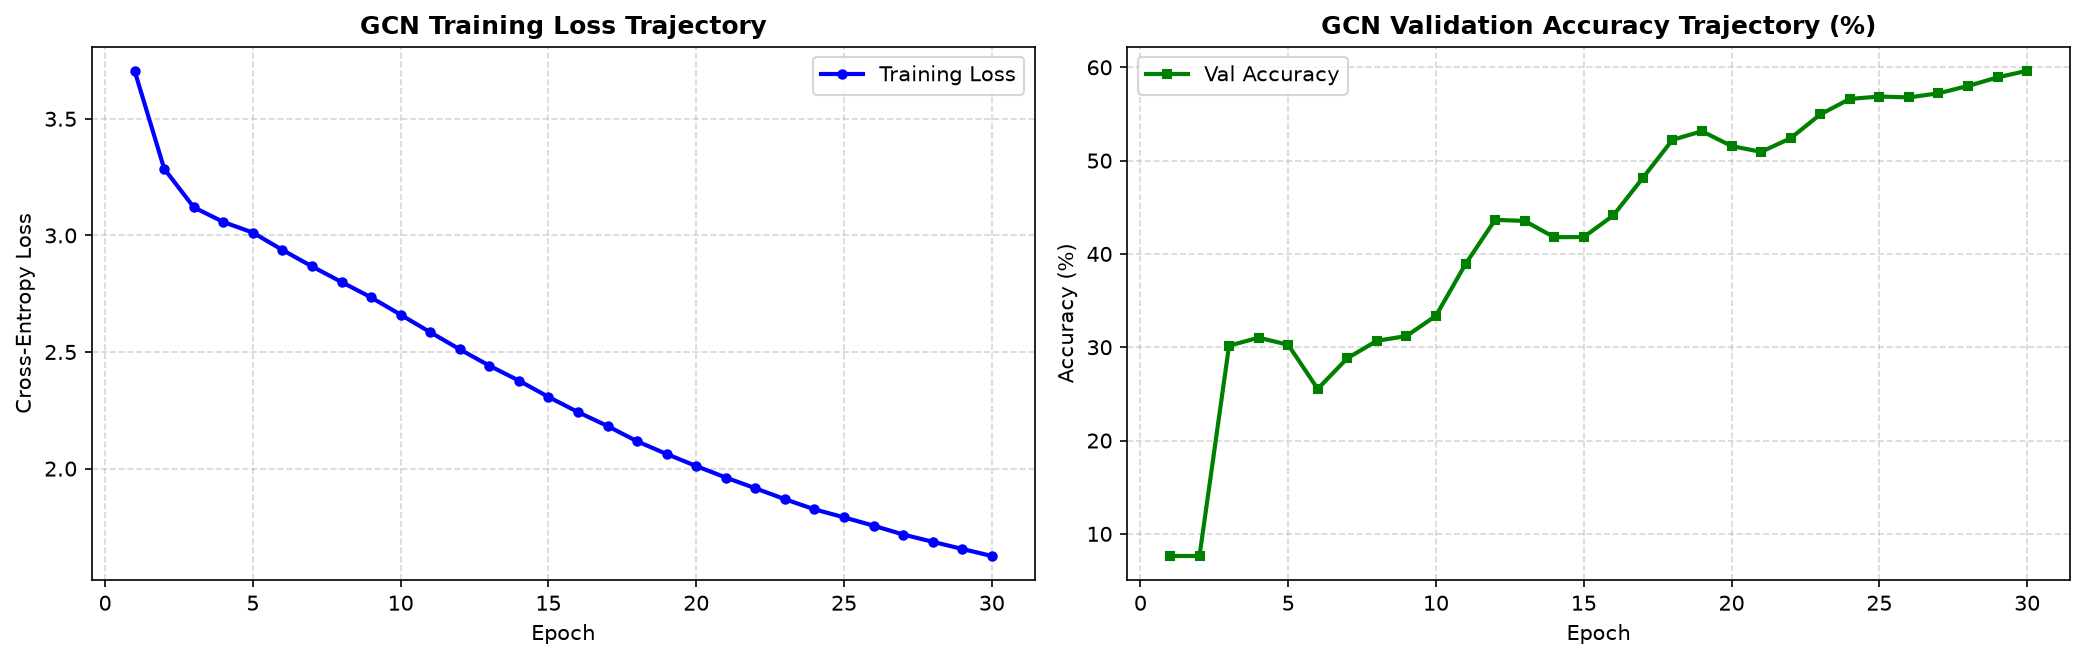

✅ Best GCN Validation Accuracy: 59.63%
✅ GCN Model Checkpoint saved to models/best_gcn.pt


In [3]:
print("🚀 Starting GCN Model Training (30 Epochs)...")
history = fit(
    model=gcn_model,
    data=data,
    split_idx=split_idx,
    epochs=30,
    learning_rate=0.01,
    checkpoint_path=MODELS_DIR / 'best_gcn.pt'
)

results_dir = RESULTS_DIR / 'training'
results_dir.mkdir(parents=True, exist_ok=True)
history.to_csv(results_dir / 'gcn_training_history.csv', index=False)

# Plot Training Loss & Validation Accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5), dpi=150)

ax1.plot(history['epoch'], history['loss'], 'b-o', lw=2, markersize=4, label='Training Loss')
ax1.set_title('GCN Training Loss Trajectory', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=10)
ax1.set_ylabel('Cross-Entropy Loss', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

ax2.plot(history['epoch'], history['validation_accuracy'] * 100, 'g-s', lw=2, markersize=4, label='Val Accuracy')
ax2.set_title('GCN Validation Accuracy Trajectory (%)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=10)
ax2.set_ylabel('Accuracy (%)', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.savefig(results_dir / 'gcn_training_plot.png', dpi=180, bbox_inches='tight')
plt.show()

print(f"✅ Best GCN Validation Accuracy: {history['validation_accuracy'].max() * 100:.2f}%")
print("✅ GCN Model Checkpoint saved to models/best_gcn.pt")